# Compare non-linear P(k) with fitting formulae

- DarkEmulator2 total non-linear P(k) is compared with CLASS HALOFIT and HMcode.
- Each pairwise comparison uses the same cosmologies, redshifts, and k grid.

## Common settings

- `sample_params_for()` draws valid DE2 cosmologies.
- HMcode sections use HMcode calibration boxes where appropriate.
- `run_class_formula()` evaluates the target formula through CLASS.

In [1]:
import random
import time

import classy
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from dark_emulator2 import DarkEmulator2

In [2]:
N_COSMO = 20
SEED = 10
REDSHIFTS = np.array([0.0, 0.5, 1.0])
KLIST = np.logspace(-2, 1, 201)

CLASS_PK_MAX = 10.0
CLASS_Z_MAX = float(np.max(REDSHIFTS) + 0.5)

In [3]:
def make_hmcode_range(version):
    version = str(version)
    if version == "2016":
        box = dict(
            omega_m=(0.120, 0.155),
            omega_b=(0.0215, 0.0235),
            Mnu=(0.0, 0.6),
            Omega_k=(-1e-4, 1e-4),
            ns=(0.85, 1.05),
            w0=(-1.3, -0.7),
            wa=(-1e-4, 1e-4),
            h0=(0.55, 0.85),
            sigma8=(0.61, 0.9),
        )
    elif version == "2020":
        box = dict(
            omega_m=(0.120, 0.155),
            omega_b=(0.0215, 0.0235),
            Mnu=(0.0, 0.4),
            Omega_k=(-1e-4, 1e-4),
            ns=(0.85, 1.05),
            w0=(-1.3, -0.7),
            wa=(-1.3, 1.15),
            h0=(0.55, 0.85),
            sigma8=(0.494, 0.9),
        )
    else:
        raise ValueError("version must be '2016' or '2020'")

    omega_m_box = box.pop("omega_m")
    box["Omega_m"] = (omega_m_box[0] / box["h0"][1]**2, omega_m_box[1] / box["h0"][0]**2)
    return box, omega_m_box


def valid_hmcode_box(p, omega_m_box):
    omega_m = p["Omega_m"] * p["h0"]**2
    return omega_m_box[0] <= omega_m <= omega_m_box[1]


def sample_params_for(range_dict=None, flags=None, valid=None, n=N_COSMO, seed=SEED, max_try=100000):
    random.seed(seed)
    np.random.seed(seed)

    emu = DarkEmulator2()
    if range_dict is None:
        range_dict = emu.param.get_preset_range_dict("preset_de2")
    if flags is None:
        flags = dict(nu=True, w0=True, wa=True, K=False)

    params = []
    ntry = 0
    with tqdm(total=n, desc="sample cosmologies") as pbar:
        while len(params) < n:
            ntry += 1
            if ntry > max_try:
                raise RuntimeError(f"Only collected {len(params)} cosmologies after {max_try} trials")

            p = emu.param.rand_param_cosmology(range_dict=range_dict, **flags)
            if valid is not None and not valid(p, emu):
                continue

            emu.get_As(p)
            p["dist"] = emu.get_power_distance(p)

            params.append(p)
            pbar.update(1)
            pbar.set_postfix(tries=ntry)

    return sorted(params, key=lambda q: q["dist"])

In [4]:
def run_de2(params, zlist=REDSHIFTS, klist=KLIST):
    emu = DarkEmulator2()
    pk_list = []
    for p in tqdm(params, desc="DE2"):
        k, pk = emu.get_pk_total(p, zred=zlist, klist=klist)
        pk_list.append(pk)
    return k, np.array(pk_list)


def run_class_formula(params, zlist=REDSHIFTS, klist=KLIST, formula="halofit", hmcode_version=None):
    pk_list = []

    for p in tqdm(params, desc=formula if hmcode_version is None else f"HMcode {hmcode_version}"):
        cosmo = classy.Class()
        cosmo.set({
            "output": "mPk",
            "P_k_max_1/Mpc": CLASS_PK_MAX,
            "z_max_pk": CLASS_Z_MAX,
            "omega_b": p["omega_b"],
            "omega_cdm": p["omega_cdm"],
            "h": p["h0"],
            "A_s": p["As"],
            "n_s": p["ns"],
            "w0_fld": p["w0"],
            "wa_fld": p["wa"],
            "Omega_k": p["Omega_k"],
            "Omega_Lambda": 0.0,
            "cs2_fld": 1.0,
            "k_pivot": 0.05,
            "m_ncdm": p["Mnu"] / 3.0,
            "N_ncdm": 1,
            "deg_ncdm": 3,
            "N_ur": 0.00641,
            "T_cmb": 2.7255,
            "tau_reio": 0.079,
        })

        if formula == "halofit":
            cosmo.set({"non_linear": "halofit"})
        elif formula == "hmcode":
            cosmo.set({"non_linear": "HMcode", "hmcode_version": str(hmcode_version)})
        else:
            raise ValueError("formula must be 'halofit' or 'hmcode'")

        cosmo.compute()
        h = p["h0"]
        pk_z = []
        for z in zlist:
            pk_z.append([cosmo.pk(k * h, z) * h**3 for k in klist])
        pk_list.append(pk_z)
        cosmo.struct_cleanup()
        cosmo.empty()

    return klist, np.array(pk_list)


def plot_comparison(result):
    k_de2, pk_de2 = result["de2"]
    k_fit, pk_fit = result["target"]
    zlist = result["redshifts"]
    label = result["label"]

    fig, axes = plt.subplots(
        2,
        len(zlist),
        figsize=(4.1 * len(zlist), 6.0),
        sharex="col",
        gridspec_kw=dict(height_ratios=[2.0, 1.0]),
    )
    if len(zlist) == 1:
        axes = np.array(axes).reshape(2, 1)

    colors = plt.cm.jet(np.linspace(0.08, 0.92, len(pk_de2)))
    for iz, z in enumerate(zlist):
        ax0 = axes[0, iz]
        ax1 = axes[1, iz]

        for i, color in enumerate(colors):
            de2 = pk_de2[i, iz]
            fit = pk_fit[i, iz]
            ax0.plot(k_de2, de2, color=color, alpha=0.55, lw=1.0)
            ax0.plot(k_fit, fit, color=color, alpha=0.55, lw=1.0, ls="--")
            ax1.plot(k_de2, fit / de2, color=color, alpha=0.65, lw=1.0)

        ax0.set_title(rf"$z={z:g}$")
        ax0.set_xscale("log")
        ax0.set_yscale("log")
        ax0.grid(True, which="major", alpha=0.35)

        ax1.axhline(1.0, color="0.2", lw=0.8)
        ax1.axhline(0.95, color="0.4", lw=0.7, ls=":")
        ax1.axhline(1.05, color="0.4", lw=0.7, ls=":")
        ax1.set_xscale("log")
        ax1.set_ylim(0.9, 1.1)
        ax1.grid(True, which="major", alpha=0.35)
        ax1.set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")

    axes[0, 0].set_ylabel(r"$P(k)\,[(h^{-1}\,\mathrm{Mpc})^3]$")
    axes[1, 0].set_ylabel(f"{label}/DE2")
    axes[0, 0].plot([], [], color="k", lw=1.3, label="DE2")
    axes[0, 0].plot([], [], color="k", lw=1.3, ls="--", label=label)
    axes[0, 0].legend(fontsize="small")

    fig.suptitle(label, y=1.02)
    fig.tight_layout()

## HALOFIT

- Evaluated with CLASS on the native DQ2 parameter range.

In [5]:
halofit_params = sample_params_for(flags=dict(nu=True, w0=True, wa=True, K=False))
len(halofit_params)

20

In [6]:
t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(halofit_params, REDSHIFTS, KLIST)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_halofit, pk_halofit = run_class_formula(halofit_params, REDSHIFTS, KLIST, formula="halofit")
halofit_time = time.perf_counter() - t0

halofit_result = dict(
    label="HALOFIT",
    de2=(k_de2, pk_de2),
    target=(k_halofit, pk_halofit),
    redshifts=REDSHIFTS,
)
print(f"DE2:     {de2_time:.2f} sec")
print(f"HALOFIT: {halofit_time:.2f} sec")

DE2:     0.80 sec
HALOFIT: 37.62 sec


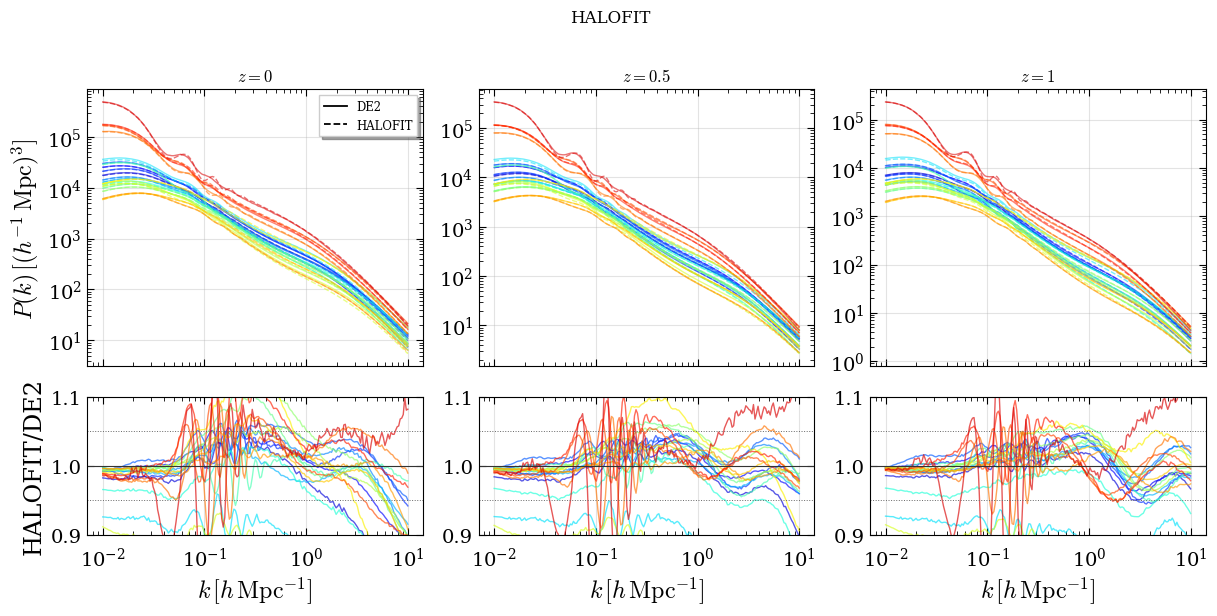

In [7]:
plot_comparison(halofit_result)

## HMcode 2016

- Evaluated with `hmcode_version="2016"`.
- Samples are restricted to the HMcode 2016 range used here.

In [8]:
hmcode2016_range, hmcode2016_omega_m = make_hmcode_range("2016")
hmcode2016_params = sample_params_for(
    range_dict=hmcode2016_range,
    flags=dict(nu=True, w0=True, wa=False, K=False),
    valid=lambda p, emu: valid_hmcode_box(p, hmcode2016_omega_m),
)
len(hmcode2016_params)

20

In [9]:
t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(hmcode2016_params, REDSHIFTS, KLIST)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_hm2016, pk_hm2016 = run_class_formula(hmcode2016_params, REDSHIFTS, KLIST, formula="hmcode", hmcode_version="2016")
hm2016_time = time.perf_counter() - t0

hmcode2016_result = dict(
    label="HMcode 2016",
    de2=(k_de2, pk_de2),
    target=(k_hm2016, pk_hm2016),
    redshifts=REDSHIFTS,
)
print(f"DE2:         {de2_time:.2f} sec")
print(f"HMcode 2016: {hm2016_time:.2f} sec")

DE2:         0.99 sec
HMcode 2016: 36.55 sec


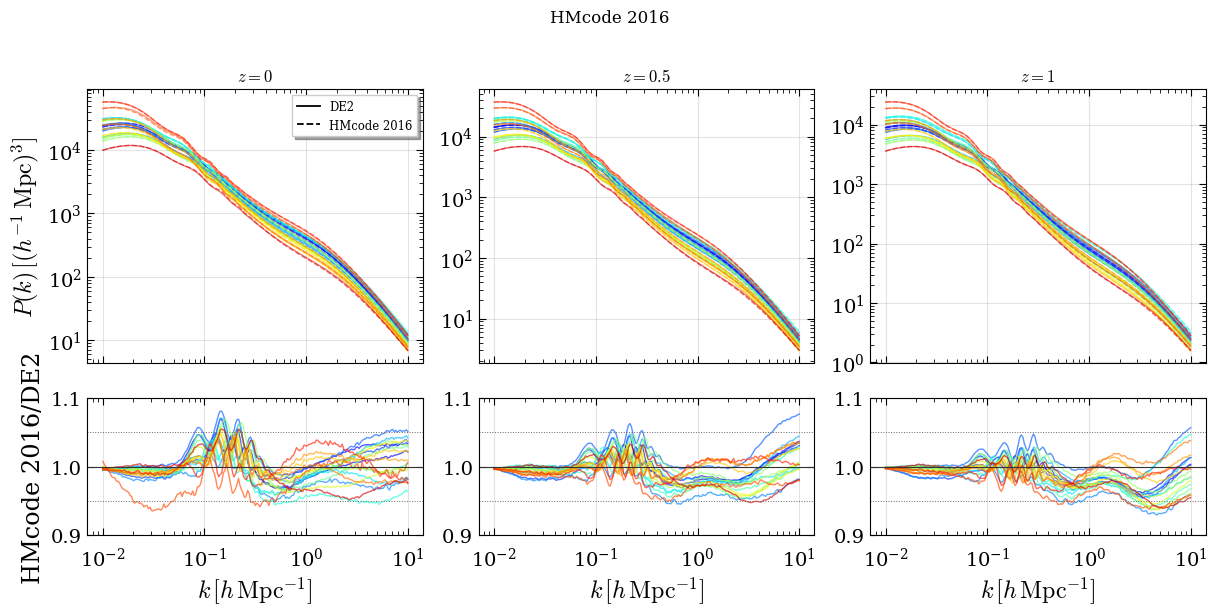

In [10]:
plot_comparison(hmcode2016_result)

## HMcode 2020

- Evaluated with `hmcode_version="2020"`.
- Samples are restricted to the HMcode 2020 range used here.

In [11]:
hmcode2020_range, hmcode2020_omega_m = make_hmcode_range("2020")
hmcode2020_params = sample_params_for(
    range_dict=hmcode2020_range,
    flags=dict(nu=True, w0=True, wa=True, K=False),
    valid=lambda p, emu: valid_hmcode_box(p, hmcode2020_omega_m),
)
len(hmcode2020_params)

20

In [12]:
t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(hmcode2020_params, REDSHIFTS, KLIST)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_hm2020, pk_hm2020 = run_class_formula(hmcode2020_params, REDSHIFTS, KLIST, formula="hmcode", hmcode_version="2020")
hm2020_time = time.perf_counter() - t0

hmcode2020_result = dict(
    label="HMcode 2020",
    de2=(k_de2, pk_de2),
    target=(k_hm2020, pk_hm2020),
    redshifts=REDSHIFTS,
)
print(f"DE2:         {de2_time:.2f} sec")
print(f"HMcode 2020: {hm2020_time:.2f} sec")

DE2:         1.02 sec
HMcode 2020: 32.56 sec


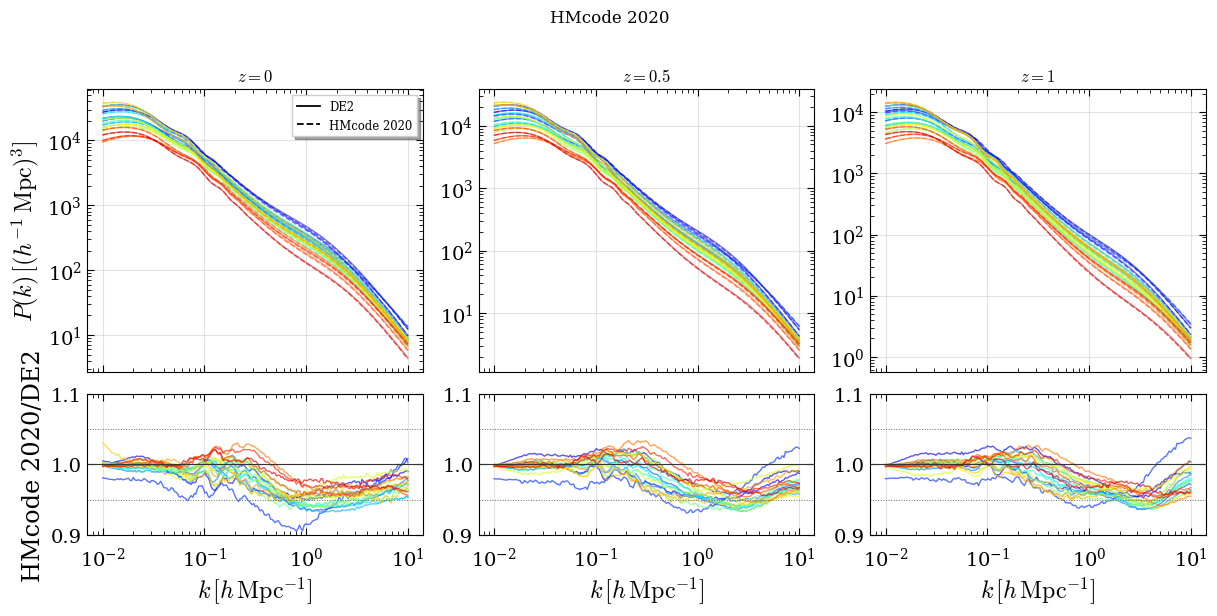

In [13]:
plot_comparison(hmcode2020_result)